# 04 — Avaliação e Interpretação

In [77]:
# ============================================================
# 1. CONFIGURAÇÃO DO AMBIENTE
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa para garantir reprodutibilidade
RANDOM_STATE = 42

# Repositório do projeto
REPO_URL = "https://github.com/andrerochadeoliveira/postech-tech-challenge-fase2-template.git"
PROJECT_PATH = Path("/content/postech-tech-challenge-fase2-template")

# Clona o repositório caso ele ainda não esteja disponível
if not PROJECT_PATH.exists():
    !git clone {REPO_URL}
else:
    print("Repositório já disponível nesta sessão.")

# Caminhos das bases
PROCESSED = PROJECT_PATH / "data" / "processed"
DATA_PATH = PROCESSED / "dataset_preprocessed.csv"

# Variável-alvo
TARGET = "target"

pd.set_option("display.max_columns", None)

print("Diretório do projeto:")
print(PROJECT_PATH)

print("\nArquivo esperado:")
print(DATA_PATH)

Repositório já disponível nesta sessão.
Diretório do projeto:
/content/postech-tech-challenge-fase2-template

Arquivo esperado:
/content/postech-tech-challenge-fase2-template/data/processed/dataset_preprocessed.csv


In [78]:
# ============================================================
# 2. EXECUÇÃO DO PRÉ-PROCESSAMENTO
# ============================================================

# Executa o notebook 02 para gerar a base pré-processada
!jupyter nbconvert \
    --to notebook \
    --execute \
    "$PROJECT_PATH/notebooks/02_preprocessamento.ipynb" \
    --output "/tmp/02_preprocessamento_executado.ipynb"

[NbConvertApp] Converting notebook /content/postech-tech-challenge-fase2-template/notebooks/02_preprocessamento.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unh

In [79]:
# ============================================================
# VERIFICAÇÃO DA BASE PRÉ-PROCESSADA
# ============================================================

print("Arquivo existe:", DATA_PATH.exists())

if DATA_PATH.exists():
    tamanho_mb = DATA_PATH.stat().st_size / (1024 ** 2)
    print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")
    print("Caminho:", DATA_PATH)
else:
    raise FileNotFoundError(
        "O arquivo dataset_preprocessed.csv não foi gerado pelo "
        "notebook 02."
    )

Arquivo existe: True
Tamanho do arquivo: 5.15 MB
Caminho: /content/postech-tech-challenge-fase2-template/data/processed/dataset_preprocessed.csv


In [80]:
# ============================================================
# 3. CARREGAMENTO E PREPARAÇÃO DA BASE
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.")
print("Dimensão:", df.shape)

# Variável alvo
y = df[TARGET]

# Variáveis preditoras
# ID e grupo_perfil não serão utilizados como preditores
X = df.drop(
    columns=[TARGET, "ID", "grupo_perfil"],
    errors="ignore"
)

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

print("\nDistribuição do target:")
print(y.value_counts())

print("\nProporção do target:")
print(y.value_counts(normalize=True))

Base carregada com sucesso.
Dimensão: (16541, 53)
Dimensão de X: (16541, 50)
Dimensão de y: (16541,)

Distribuição do target:
target
0    15233
1     1308
Name: count, dtype: int64

Proporção do target:
target
0    0.920924
1    0.079076
Name: proportion, dtype: float64


In [81]:
# ============================================================
# 4. REPRODUÇÃO DO SPLIT TREINO/TESTE
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

# Recupera os grupos cadastrais
grupos = df["grupo_perfil"]

# Mesma configuração utilizada no notebook 03
divisor = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Seleciona o primeiro fold para teste
idx_train, idx_test = next(
    divisor.split(X, y, groups=grupos)
)

# Separa preditores e variável-alvo
X_train = X.iloc[idx_train]
X_test = X.iloc[idx_test]

y_train = y.iloc[idx_train]
y_test = y.iloc[idx_test]

# Preserva os identificadores dos grupos
grupos_train = grupos.iloc[idx_train]
grupos_test = grupos.iloc[idx_test]

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nProporção de positivos:")
print("Treino:", round(y_train.mean(), 4))
print("Teste:", round(y_test.mean(), 4))

# Verifica se houve compartilhamento de perfis
grupos_comuns = set(grupos_train).intersection(
    set(grupos_test)
)

print("\nPerfis compartilhados:", len(grupos_comuns))

assert len(grupos_comuns) == 0, (
    "Erro: existem perfis cadastrais "
    "compartilhados entre treino e teste."
)

print("\nDivisão validada com sucesso!")

Treino: (13255, 50)
Teste: (3286, 50)

Proporção de positivos:
Treino: 0.0752
Teste: 0.0946

Perfis compartilhados: 0

Divisão validada com sucesso!


In [82]:
# ============================================================
# 5. MODELO FINAL
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Modelo selecionado no notebook 03
modelo_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Treina exclusivamente com os dados de treinamento
modelo_final.fit(X_train, y_train)

print("Modelo final treinado com sucesso.")
print("Algoritmo: Regressão Logística")
print("Balanceamento: class_weight='balanced'")


Modelo final treinado com sucesso.
Algoritmo: Regressão Logística
Balanceamento: class_weight='balanced'


In [83]:
# ============================================================
# 6. PREVISÕES NO CONJUNTO DE TESTE
# ============================================================

# Threshold selecionado no treinamento do notebook 03
THRESHOLD = 0.51

# Probabilidades da classe positiva
y_prob = modelo_final.predict_proba(X_test)[:, 1]

# Classificação pelo threshold selecionado
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f"Threshold utilizado: {THRESHOLD}")
print(f"Quantidade de observações no teste: {len(y_test):,}")
print(f"Quantidade prevista como classe 1: {y_pred.sum():,}")


Threshold utilizado: 0.51
Quantidade de observações no teste: 3,286
Quantidade prevista como classe 1: 1,060


# Métricas no conjunto de teste

A avaliação é realizada no conjunto de teste, que não participou da seleção do modelo nem da definição do ponto de corte. Como a variável-alvo apresenta forte desbalanceamento, são priorizadas métricas que permitem avaliar a identificação da classe positiva, especialmente Precision, Recall e F1-score.

In [84]:
# ============================================================
# 7. MÉTRICAS NO CONJUNTO DE TESTE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

metricas_teste = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision
    ]
})

metricas_teste.round(4)

,Métrica,Valor
0,Accuracy,0.6595
1,Precision,0.1189
2,Recall,0.4051
3,F1-score,0.1838
4,ROC-AUC,0.5814
5,Average Precision,0.1556


## 2. Justificativa das métricas

Neste problema, a variável-alvo apresenta desbalanceamento, com aproximadamente **7,91% dos registros pertencentes à classe positiva**. Por esse motivo, a acurácia isoladamente não é adequada para avaliar a qualidade do modelo, pois uma classificação predominantemente voltada à classe majoritária poderia produzir uma acurácia elevada mesmo com baixa capacidade de identificar os casos positivos.

A **Precision** foi utilizada para avaliar a proporção de classificações positivas que realmente correspondem à classe de interesse. O **Recall** mede a capacidade do modelo de identificar os casos positivos existentes. O **F1-score** combina Precision e Recall e foi utilizado como principal métrica para a seleção do modelo e do ponto de corte.

Também foram utilizadas **ROC-AUC** e **Average Precision** para avaliar a capacidade discriminativa do modelo a partir das probabilidades estimadas, independentemente do ponto de corte utilizado.

Neste contexto, os **falsos negativos** são particularmente relevantes, pois representam casos positivos que não foram identificados pelo modelo. Entretanto, os falsos positivos também possuem custo operacional, uma vez que uma quantidade excessiva de alertas pode reduzir a efetividade de uma eventual estratégia de análise ou intervenção.

Por esse motivo, o objetivo não é simplesmente maximizar o Recall ou a Precision isoladamente, mas buscar um equilíbrio entre essas métricas, justificando a utilização do F1-score como principal critério de seleção.

## 3. Matriz de confusão

A matriz de confusão permite avaliar como o modelo classificou os registros do conjunto de teste, distinguindo **verdadeiros positivos, falsos positivos, verdadeiros negativos e falsos negativos**.

Como o problema apresenta desbalanceamento, a análise dos erros da classe positiva é particularmente importante. O modelo utiliza o ponto de corte de **0,51**, definido na etapa de modelagem a partir das previsões *out-of-fold* do conjunto de treinamento, sem utilização do conjunto de teste para essa escolha.

Matriz de confusão:
[[2041  934]
 [ 185  126]]

Detalhamento:
Verdadeiros negativos (TN): 2,041
Falsos positivos (FP):      934
Falsos negativos (FN):      185
Verdadeiros positivos (TP): 126


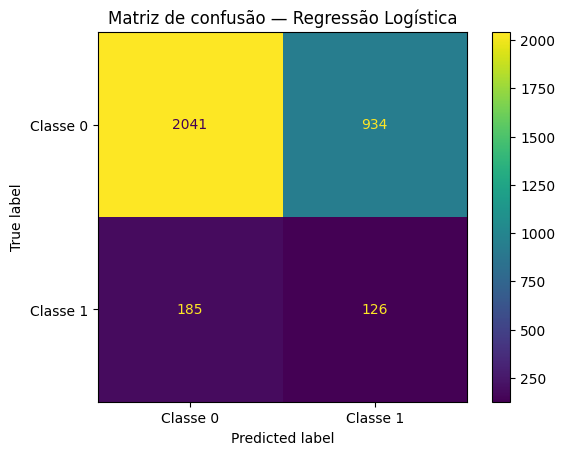

In [85]:
# ============================================================
# 8. MATRIZ DE CONFUSÃO
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Matriz de confusão:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nDetalhamento:")
print(f"Verdadeiros negativos (TN): {tn:,}")
print(f"Falsos positivos (FP):      {fp:,}")
print(f"Falsos negativos (FN):      {fn:,}")
print(f"Verdadeiros positivos (TP): {tp:,}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Classe 0", "Classe 1"]
)

disp.plot(values_format="d")

plt.title("Matriz de confusão — Regressão Logística")
plt.show()

### Interpretação da matriz de confusão

No conjunto de teste, o modelo classificou corretamente **2.041 registros da classe 0** e **126 registros da classe 1**. Foram observados **934 falsos positivos** e **185 falsos negativos**.

Dos 311 casos efetivamente pertencentes à classe positiva no conjunto de teste, o modelo identificou 126, correspondendo a um **Recall de 40,51%**. Entre os 1.060 registros classificados como positivos, 126 eram de fato positivos, resultando em **Precision de 11,89%**.

Os resultados mostram que o modelo apresenta capacidade limitada de discriminação entre as classes. Embora consiga identificar aproximadamente quatro em cada dez casos positivos, produz uma quantidade elevada de falsos positivos, o que representa uma limitação relevante para sua aplicação operacional.

Portanto, sua eventual utilização deve ser interpretada como uma ferramenta experimental de **priorização e apoio à análise**, e não como mecanismo isolado de decisão.

A matriz também evidencia a necessidade de considerar o equilíbrio entre os custos dos falsos positivos e dos falsos negativos. Em uma aplicação prática, a definição do ponto de corte deve considerar o objetivo da área, a capacidade operacional de análise e o custo associado a cada tipo de erro.

## 4. Importância das variáveis

A importância das variáveis foi analisada inicialmente a partir dos **coeficientes da Regressão Logística**, modelo selecionado na etapa de modelagem.

Como o modelo utiliza a padronização das variáveis por meio do `StandardScaler`, os coeficientes podem ser comparados em termos de magnitude, considerando as limitações decorrentes de correlações entre variáveis explicativas.

Coeficientes positivos indicam associação com o aumento das chances estimadas de pertencimento à classe positiva, mantendo constantes as demais variáveis. Coeficientes negativos indicam associação em sentido contrário.

A magnitude absoluta dos coeficientes foi utilizada para identificar as variáveis com maior influência na função de decisão do modelo.

É importante destacar que essa análise representa **associações estatísticas identificadas pelo modelo**, não constituindo evidência de causalidade.

In [86]:
# ============================================================
# 9. IMPORTÂNCIA DAS VARIÁVEIS — REGRESSÃO LOGÍSTICA
# ============================================================

import pandas as pd

# Recupera os coeficientes do classificador
coeficientes = modelo_final.named_steps["clf"].coef_[0]

# Associa cada coeficiente à respectiva variável
importances = pd.Series(
    coeficientes,
    index=X_train.columns
)

# Ordena pela magnitude absoluta dos coeficientes
importances = importances.reindex(
    importances.abs().sort_values(ascending=False).index
)

print("Top 15 variáveis por magnitude do coeficiente:")

display(
    importances.head(15)
    .to_frame("coeficiente")
    .round(4)
)

Top 15 variáveis por magnitude do coeficiente:


,coeficiente
NAME_EDUCATION_TYPE_Secondary / secondary special,0.8832
Employed,0.8739
NAME_INCOME_TYPE_Pensioner,0.8674
NAME_EDUCATION_TYPE_Higher education,0.7740
Ratio_life_employed,-0.7642
Year_employed,0.7186
OCCUPATION_TYPE_HR staff,-0.4507
NAME_EDUCATION_TYPE_Incomplete higher,0.4174
OCCUPATION_TYPE_Realty agents,-0.3547
Age,-0.3296


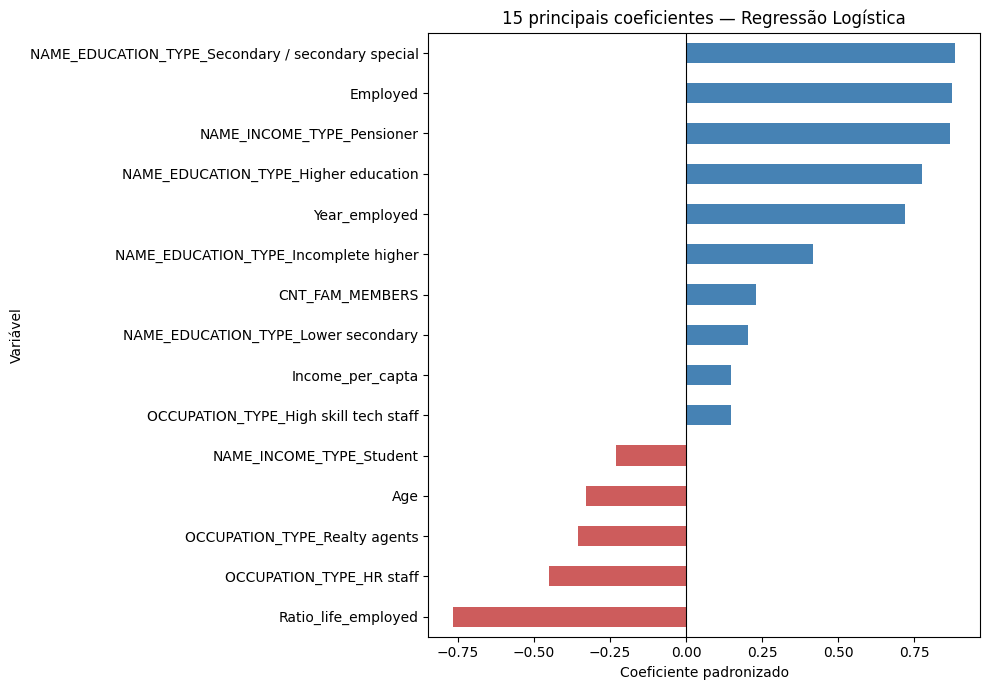

In [87]:
# ============================================================
# GRÁFICO DOS COEFICIENTES DA REGRESSÃO LOGÍSTICA
# ============================================================

import matplotlib.pyplot as plt

top_n = 15

top_features = (
    importances
    .head(top_n)
    .sort_values()
)

plt.figure(figsize=(10, 7))

cores = [
    "steelblue" if valor > 0 else "indianred"
    for valor in top_features
]

top_features.plot(
    kind="barh",
    color=cores
)

plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("Coeficiente padronizado")
plt.ylabel("Variável")
plt.title("15 principais coeficientes — Regressão Logística")

plt.tight_layout()
plt.show()

### Interpretação das principais variáveis

A análise dos coeficientes padronizados da Regressão Logística identificou como variáveis de maior magnitude absoluta:

- **NAME_EDUCATION_TYPE_Secondary / secondary special:** coeficiente de +0,8832.
- **Employed:** coeficiente de +0,8739.
- **NAME_INCOME_TYPE_Pensioner:** coeficiente de +0,8674.
- **NAME_EDUCATION_TYPE_Higher education:** coeficiente de +0,7740.
- **Ratio_life_employed:** coeficiente de −0,7642.

Esses resultados indicam que características relacionadas à **escolaridade, situação profissional e relação entre idade e tempo de emprego** apresentam associações relevantes com a classificação produzida pelo modelo.

Os coeficientes positivos representam associações com maiores chances estimadas de pertencimento à classe positiva, enquanto os negativos representam associações em sentido contrário, mantidas constantes as demais variáveis.

Entretanto, esses resultados exigem cautela. A presença de variáveis correlacionadas, especialmente indicadores de situação profissional e escolaridade, pode influenciar a magnitude e a estabilidade dos coeficientes individuais.

Além disso, as variáveis categóricas transformadas em indicadores binários devem ser interpretadas considerando sua categoria de referência e as demais características incluídas no modelo.

Portanto, os coeficientes permitem compreender a estrutura estatística da Regressão Logística, mas não demonstram relações causais nem devem ser interpretados isoladamente como fatores determinantes do comportamento de crédito.

### Validação da importância das variáveis

Como análise complementar aos coeficientes da Regressão Logística, foi utilizada a técnica de **Permutation Importance**.

Essa técnica avalia a contribuição preditiva de cada variável por meio do embaralhamento aleatório de seus valores, mantendo as demais características inalteradas. A importância é estimada pela redução do desempenho do modelo provocada por essa alteração.

Foi utilizada a **Average Precision** como métrica de referência, por sua adequação à avaliação de classificadores em problemas com classes desbalanceadas.

A análise foi realizada no conjunto de teste exclusivamente para fins de interpretação, sem modificar o modelo, seus parâmetros ou o ponto de corte previamente selecionado.

Diferentemente dos coeficientes da Regressão Logística, a Permutation Importance considera diretamente o impacto de cada variável sobre o desempenho preditivo, oferecendo uma perspectiva complementar para a interpretação do modelo.

In [88]:
# ============================================================
# 10. PERMUTATION IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance

permutation = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importances = pd.Series(
    permutation.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print("Top 15 variáveis pela Permutation Importance:")

display(
    permutation_importances
    .head(15)
    .to_frame("importance_mean")
    .round(4)
)

Top 15 variáveis pela Permutation Importance:


,importance_mean
Employed,0.0557
Ratio_life_employed,0.0478
NAME_EDUCATION_TYPE_Higher education,0.0461
Year_employed,0.0447
NAME_EDUCATION_TYPE_Incomplete higher,0.0338
NAME_INCOME_TYPE_Pensioner,0.0301
Age,0.0249
NAME_EDUCATION_TYPE_Secondary / secondary special,0.0224
CNT_FAM_MEMBERS,0.0208
NAME_HOUSING_TYPE_House / apartment,0.0186


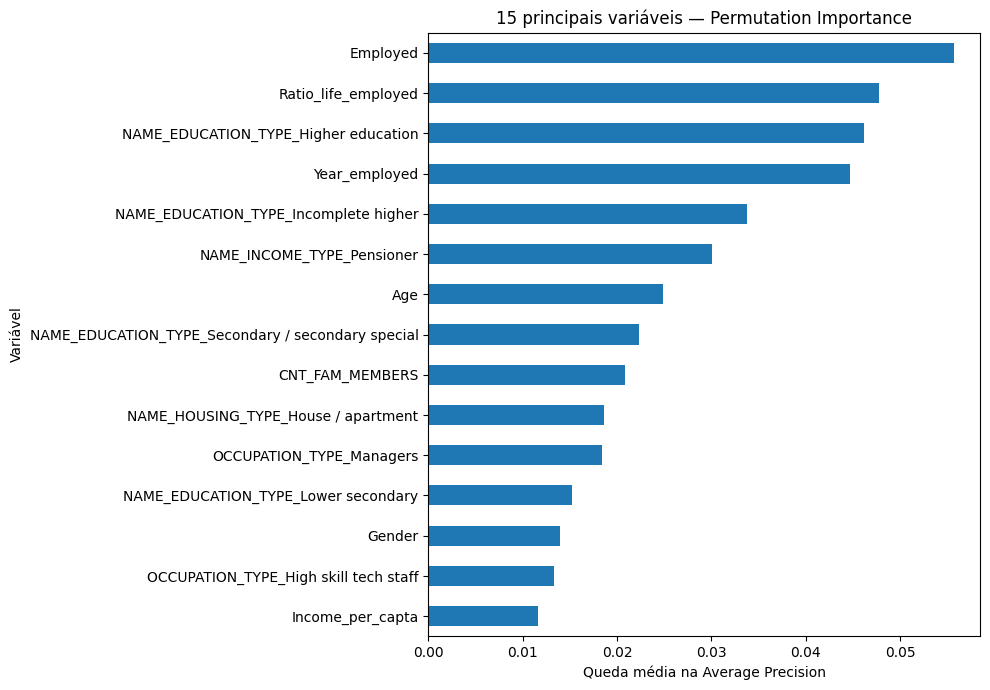

In [89]:
# ============================================================
# GRÁFICO — PERMUTATION IMPORTANCE
# ============================================================

top_features_perm = (
    permutation_importances
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

top_features_perm.plot(kind="barh")

plt.xlabel("Queda média na Average Precision")
plt.ylabel("Variável")
plt.title("15 principais variáveis — Permutation Importance")
plt.tight_layout()
plt.show()

## 5. Implicações práticas

### Comparação entre as medidas de importância

A comparação entre os coeficientes padronizados da Regressão Logística e a Permutation Importance apresentou convergência em diversas variáveis relevantes.

As variáveis **Employed**, **Ratio_life_employed**, **NAME_EDUCATION_TYPE_Higher education** e **Year_employed** apresentaram destaque nas duas abordagens, indicando que características relacionadas à situação profissional, escolaridade e tempo de emprego possuem relevância para as previsões do modelo.

Na análise por Permutation Importance, as maiores reduções médias na Average Precision foram observadas nas seguintes variáveis:

- **Employed:** 0,0557.
- **Ratio_life_employed:** 0,0478.
- **NAME_EDUCATION_TYPE_Higher education:** 0,0461.
- **Year_employed:** 0,0447.
- **NAME_EDUCATION_TYPE_Incomplete higher:** 0,0338.

As diferenças entre os rankings são esperadas, pois os métodos avaliam aspectos distintos. Enquanto os coeficientes representam associações na função de decisão da Regressão Logística, a Permutation Importance mede a contribuição de cada variável para o desempenho preditivo.

Também é importante considerar que a presença de variáveis correlacionadas pode afetar os resultados da análise por permutação, uma vez que o embaralhamento individual de uma variável não elimina as informações semelhantes disponíveis nas demais.

A Permutation Importance foi utilizada exclusivamente para interpretação, não para selecionar ou alterar o modelo final.

Por fim, ambas as análises representam **associações ou contribuições preditivas**, não permitindo estabelecer relações causais entre as características observadas e a ocorrência da classe positiva.

### Como utilizar o modelo

Os resultados indicam que a Regressão Logística com ponderação de classes apresenta capacidade limitada de identificação da classe positiva, podendo ser considerada, em caráter experimental, como instrumento de apoio à priorização de análises.

Com o ponto de corte de **0,51**, definido durante a etapa de modelagem, o classificador identificou **126 dos 311 registros positivos** existentes no conjunto de teste, correspondendo a um **Recall de 40,51%**. Entretanto, entre os **1.060 registros classificados como positivos**, apenas 126 pertenciam efetivamente à classe positiva, resultando em **Precision de 11,89%**.

Isso significa que aproximadamente **88,11% dos alertas gerados seriam falsos positivos**, representando uma limitação operacional importante. Além disso, o modelo deixou de identificar 185 registros positivos, correspondentes a 59,49% dos casos positivos do conjunto de teste.

Na prática, uma eventual aplicação exigiria avaliação cuidadosa dos custos associados aos falsos positivos e falsos negativos, bem como da capacidade operacional de tratamento dos alertas.

O desempenho discriminativo também é limitado, conforme indicado pelo **ROC-AUC de 0,5814**. Portanto, os resultados não sustentam a utilização do modelo como mecanismo autônomo de aprovação ou reprovação de crédito.

Uma possível aplicação futura seria a utilização das probabilidades estimadas para apoiar a organização de filas de análise, desde que acompanhada de validações adicionais, monitoramento de desempenho e critérios de negócio.

O ponto de corte não deve ser considerado definitivo para utilização operacional. Em uma aplicação real, sua definição precisaria considerar os custos associados aos diferentes tipos de erro, a capacidade de análise disponível e os objetivos da instituição.

Assim, o modelo deve ser entendido como um **resultado experimental de classificação**, com potencial de aprimoramento, e não como uma solução pronta para implantação.

## 6. Limitações

### Limitações do modelo

O desempenho obtido apresenta limitações importantes que devem ser consideradas antes de qualquer utilização prática.

**1. Capacidade limitada de identificação da classe positiva**

O Recall de 40,51% indica que o modelo identificou 126 dos 311 casos positivos existentes no conjunto de teste. Consequentemente, 185 registros positivos não foram identificados, representando 59,49% dos casos dessa classe.

**2. Baixa Precision e elevada quantidade de falsos positivos**

A Precision de 11,89% indica que apenas uma pequena parcela dos registros classificados como positivos realmente pertence à classe de interesse. Foram observados 934 falsos positivos, o que poderia gerar custos operacionais significativos em uma eventual aplicação.

**3. Desbalanceamento da variável-alvo**

Na base pré-processada, a classe positiva representa aproximadamente 7,91% das observações. Esse desbalanceamento dificulta a identificação da classe minoritária e torna inadequada a utilização da acurácia como principal critério de avaliação.

**4. Capacidade discriminativa limitada**

O ROC-AUC de 0,5814 indica desempenho apenas modestamente superior ao de um classificador aleatório em termos de ordenação dos casos positivos e negativos. A Average Precision de 0,1556 também evidencia limitações na identificação da classe positiva.

**5. Limitações das variáveis disponíveis**

O desempenho obtido sugere que as variáveis explicativas disponíveis possuem capacidade preditiva limitada. A inclusão de informações adicionais, especialmente relacionadas ao histórico de comportamento de crédito, poderia contribuir para o desenvolvimento de modelos mais discriminativos.

**6. Dependência da estratégia de construção da variável-alvo**

Durante o pré-processamento, registros com o mesmo perfil cadastral foram agrupados e receberam a classificação positiva quando pelo menos um registro do grupo apresentava essa condição.

Essa estratégia foi adotada para tratar a inconsistência entre registros cadastrais equivalentes, mas modifica a interpretação da variável-alvo e pode influenciar o desempenho dos modelos.

Consequentemente, os resultados devem ser interpretados considerando essa definição operacional da classe positiva.

**7. Limitações de generalização**

Embora tenha sido utilizada uma divisão treino/teste que impede o compartilhamento de perfis cadastrais entre os conjuntos, os resultados foram obtidos sobre uma única base de dados. Não foi realizada validação temporal ou externa que permita avaliar a estabilidade do desempenho em outras populações ou períodos.

**8. Importância das variáveis não representa causalidade**

Os coeficientes da Regressão Logística e os resultados da Permutation Importance permitem analisar associações estatísticas e contribuições preditivas, mas não demonstram relações causais entre as características dos indivíduos e o comportamento de crédito.

### Possíveis melhorias

Como oportunidades para trabalhos futuros, destacam-se:

- Inclusão de novas variáveis com maior capacidade preditiva, especialmente informações comportamentais e históricas.
- Avaliação de algoritmos adicionais, incluindo métodos de boosting.
- Investigação de estratégias alternativas para o tratamento do desbalanceamento.
- Avaliação da calibração das probabilidades estimadas.
- Estudo de diferentes pontos de corte considerando custos operacionais e objetivos de negócio.
- Realização de validações temporais e externas.
- Monitoramento de estabilidade e desempenho em novas amostras.
- Investigação dos efeitos da estratégia de agrupamento e classificação dos perfis cadastrais.

Essas possibilidades representam oportunidades de aprimoramento e não alteram os resultados obtidos nesta etapa do trabalho.

## Conclusão executiva

O presente trabalho avaliou diferentes estratégias de classificação para identificação da classe positiva em uma base de dados de crédito, considerando o desbalanceamento da variável-alvo e a necessidade de evitar o compartilhamento de perfis cadastrais equivalentes entre treinamento e teste.

Foram comparadas seis configurações de modelos, envolvendo Regressão Logística e Random Forest, com abordagens baseline, ponderação de classes e aplicação de SMOTE.

Entre as alternativas avaliadas, a **Regressão Logística com ponderação de classes** apresentou o melhor desempenho médio de F1-score na validação cruzada, atingindo aproximadamente **0,1485**.

O ponto de corte de **0,51** foi selecionado a partir das previsões *out-of-fold* do conjunto de treinamento, sem utilização dos dados de teste para sua definição.

Na avaliação final, realizada sobre **3.286 registros de teste**, o modelo apresentou **F1-score de 0,1838**, **Precision de 11,89%**, **Recall de 40,51%**, **ROC-AUC de 0,5814** e **Average Precision de 0,1556**.

A matriz de confusão evidenciou a identificação correta de 126 dos 311 registros positivos, acompanhada de 934 falsos positivos e 185 falsos negativos. Esses resultados demonstram que, embora o modelo apresente alguma capacidade de discriminação, seu desempenho ainda é insuficiente para sustentar decisões automáticas de crédito.

A análise interpretativa identificou contribuições relevantes de variáveis relacionadas à situação profissional, escolaridade e tempo de emprego, tanto por meio dos coeficientes padronizados da Regressão Logística quanto pela técnica de Permutation Importance. Essas relações devem ser compreendidas como associações estatísticas e não como evidências de causalidade.

A principal contribuição do trabalho consiste na construção e avaliação de um processo de classificação que incorpora tratamento do desbalanceamento, validação com separação por perfis cadastrais e análise interpretativa do modelo selecionado.

Conclui-se que o modelo desenvolvido possui **caráter experimental**, apresentando limitações importantes de desempenho e generalização. Sua eventual utilização como instrumento de apoio à priorização de análises dependeria de aprimoramentos metodológicos, validações adicionais e avaliação dos custos operacionais associados aos erros de classificação.